In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.ndimage import gaussian_filter1d
import GPy
import matplotlib.pyplot as plt
import seaborn as sns # ## --- CAMBIO: NUEVO --- ##
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera # Ya corregido
from statsmodels.graphics.tsaplots import plot_acf # ## --- CAMBIO: NUEVO --- ##
import warnings

Filtrar FutureWarnings (opcional, si persisten por otras librerías)
warnings.simplefilter(action='ignore', category=FutureWarning)

--- Funciones de Preprocesamiento y Modelado ---

In [2]:
def parse_spatial_temporal_ids(df):
    """
    Adapta el DataFrame para usar 'zone_id' como spatial_id y 'year_week' para temporal_id_numeric.
    """
    df_copy = df.copy()

    # Usar 'zone_id' directamente como spatial_id
    if 'zone_id' in df_copy.columns:
        df_copy['spatial_id'] = df_copy['zone_id'].astype(str)
    else:
        print("Advertencia: 'zone_id' no encontrada. Usando un ID espacial genérico.")
        df_copy['spatial_id'] = 'unknown_spatial_id_' + df_copy.index.astype(str)

    # Convertir 'year_week' a fecha y luego a temporal_id_numeric
    if 'year_week' in df_copy.columns:
        try:
            # '%w' para el día de la semana (0=Domingo, 6=Sábado). '-1' asumirá el lunes.
            df_copy['week_start_date'] = pd.to_datetime(df_copy['year_week'].astype(str) + '-1', format='%Y-%W-%w')
        except ValueError:
            print("Advertencia: No se pudo parsear 'year_week' a fecha. Usando factorize para temporal_id_numeric.")
            df_copy['week_start_date'] = pd.NaT

        min_date = df_copy['week_start_date'].dropna().min()
        if pd.isna(min_date):
            df_copy['temporal_id_numeric'] = pd.factorize(df_copy['year_week'].astype(str))[0]
        else:
            df_copy['temporal_id_numeric'] = (df_copy['week_start_date'] - min_date).dt.days // 7
            df_copy.loc[df_copy['temporal_id_numeric'].isnull(), 'temporal_id_numeric'] = -1

    else:
        print("Advertencia: 'year_week' no encontrada. Usando un ID temporal numérico genérico.")
        df_copy['temporal_id_numeric'] = np.arange(len(df_copy))

    df_copy.sort_values(by=['spatial_id', 'temporal_id_numeric'], inplace=True, na_position='first')
    df_copy.drop(columns=['week_start_date', 'year_week', 'zone_id'], inplace=True, errors='ignore')

    return df_copy

In [3]:
def clean_col_names(df, cols_to_clean):
    df_cleaned = df.copy()
    rename_map = {}
    cleaned_cols = []
    if not isinstance(cols_to_clean, list): cols_to_clean = []

    for col in cols_to_clean:
        if col is None or col not in df_cleaned.columns: continue
        new_col_name = str(col).replace('(F)', '_F') \
                               .replace('(mph)', '_mph') \
                               .replace('(in)', '_in') \
                               .replace('(%)', '_percent') \
                               .replace('[', '_').replace(']', '_') \
                               .replace('(', '').replace(')', '') \
                               .replace('%', 'percent').replace('/', '_').replace('-','_')
        rename_map[col] = new_col_name
        cleaned_cols.append(new_col_name)
    df_cleaned.rename(columns=rename_map, inplace=True)
    return df_cleaned, cleaned_cols

In [4]:
def preprocess_data(df, outcome_col, spatial_col, temporal_col, covar_cols, transformation='log'):
    processed_df = df.copy()
    if processed_df.empty: return processed_df, {}, ""
    if not covar_cols: covar_cols = []

    numeric_covars = processed_df[covar_cols].select_dtypes(include=np.number).columns.tolist()
    if len(numeric_covars) > 0:
        imputer_mean = SimpleImputer(strategy='mean')
        if processed_df[numeric_covars].isnull().values.any():
            processed_df[numeric_covars] = imputer_mean.fit_transform(processed_df[numeric_covars])

    categorical_covars = processed_df[covar_cols].select_dtypes(exclude=np.number).columns.tolist()
    if len(categorical_covars) > 0:
        imputer_mode = SimpleImputer(strategy='most_frequent')
        for col in categorical_covars:
            if processed_df[col].isnull().any():
                processed_df[col] = imputer_mode.fit_transform(processed_df[[col]])
            processed_df[col] = pd.factorize(processed_df[col].astype(str))[0]

    cols_to_check_critical_nan = [outcome_col, spatial_col, temporal_col]
    existing_critical_cols = [col for col in cols_to_check_critical_nan if col in processed_df.columns]
    processed_df.dropna(subset=existing_critical_cols, inplace=True)

    if processed_df.empty: return processed_df, {}, ""

    transformed_outcome_col_name = f'{outcome_col}_transformed'
    if transformation == 'log':
        processed_df[transformed_outcome_col_name] = np.log1p(processed_df[outcome_col])
    elif transformation == 'logit':
        epsilon = 1e-6
        prob = np.clip(processed_df[outcome_col].astype(float), epsilon, 1 - epsilon)
        processed_df[transformed_outcome_col_name] = np.log(prob / (1 - prob))
    else:
        processed_df[transformed_outcome_col_name] = processed_df[outcome_col]

    if processed_df[transformed_outcome_col_name].empty or processed_df[transformed_outcome_col_name].isnull().all():
        global_data_variance = 0.01
    else:
        global_data_variance = np.var(processed_df[transformed_outcome_col_name].dropna())
        if pd.isna(global_data_variance) or global_data_variance == 0:
            global_data_variance = 0.01

    data_variance_map = {}
    if spatial_col in processed_df.columns and temporal_col in processed_df.columns:
        for idx, row in processed_df.iterrows():
            spatial_key = row[spatial_col] if not pd.isna(row[spatial_col]) else "unknown_spatial"
            temporal_key = row[temporal_col] if not pd.isna(row[temporal_col]) else -1
            data_variance_map[(spatial_key, temporal_key)] = global_data_variance + np.random.uniform(0.001, 0.01)

    return processed_df, data_variance_map, transformed_outcome_col_name

In [5]:
def run_stage1_regression(df, transformed_outcome_col, spatial_col, temporal_col, covar_cols, model_type='OLS'):
    if df.empty or transformed_outcome_col not in df.columns or temporal_col not in df.columns:
        return pd.Series(index=df.index if not df.empty else None, dtype=float, name='stage1_preds')
    
    min_obs_for_regression = max(2, len(covar_cols) + 2 if covar_cols else 2)
    if len(df.dropna(subset=[transformed_outcome_col, temporal_col])) < min_obs_for_regression :
        return pd.Series(np.nan, index=df.index, name='stage1_preds')

    safe_covar_cols = []
    if covar_cols:
        for col in covar_cols:
            if col in df.columns:
                if df[col].dropna().nunique() > 1 :
                    safe_covar_cols.append(f'`{col}`')
                elif df[col].dropna().nunique() == 1 and pd.api.types.is_numeric_dtype(df[col].dropna()):
                    safe_covar_cols.append(f'`{col}`')

    formula = f"`{transformed_outcome_col}` ~ 1 + `{temporal_col}`"
    if safe_covar_cols:
        formula += f" + {' + '.join(safe_covar_cols)}"

    stage1_preds = pd.Series(np.nan, index=df.index, name='stage1_preds')

    try:
        if model_type == 'OLS':
            if spatial_col in df.columns and df[spatial_col].nunique() > 1 and df[spatial_col].nunique() < len(df) / 5 :
                formula += f" + C(`{spatial_col}`)"
            
            formula_cols = [transformed_outcome_col, temporal_col] + [c.strip('`').replace('\\','') for c in safe_covar_cols]
            if spatial_col in df.columns and f"C(`{spatial_col}`)" in formula: formula_cols.append(spatial_col)
            
            model_df = df[formula_cols].dropna()
            
            if len(model_df) < min_obs_for_regression:
                raise ValueError("Not enough data to run OLS regression after NA drop.")

            model = smf.ols(formula, data=model_df).fit()
            stage1_preds.update(model.predict(df))
                                                
        elif model_type == 'MixedLM':
            if spatial_col in df.columns:
                df[spatial_col] = df[spatial_col].astype('category')
                model = smf.mixedlm(formula, data=df, groups=df[spatial_col], missing='drop').fit(reml=False)
                stage1_preds.update(model.predict(df))
            else:
                model = smf.ols(formula, data=df, missing='drop').fit()
                stage1_preds.update(model.predict(df))
    except Exception as e:
        try:
            simple_formula_parts = [f"`{transformed_outcome_col}` ~ 1", f"`{temporal_col}`"]
            if spatial_col in df.columns and df[spatial_col].nunique() > 1 and df[spatial_col].nunique() < len(df) / 5:
                simple_formula_parts.append(f"C(`{spatial_col}`)")
            simple_formula = " + ".join(filter(None,simple_formula_parts))
            
            model_df_fallback = df[[c.strip('`').replace('\\','') for c in simple_formula_parts if '`' in c]].dropna()
            if len(model_df_fallback) < min_obs_for_regression:
                raise ValueError("Not enough data for fallback OLS regression.")

            model = smf.ols(simple_formula, data=model_df_fallback).fit()
            stage1_preds.update(model.predict(df))
        except Exception as e_fallback:
            stage1_preds.fillna(df[transformed_outcome_col].mean(), inplace=True)

    stage1_preds.name = 'stage1_preds'
    return stage1_preds

In [6]:
def run_stage2_smoothing(df, stage1_preds, transformed_outcome_col, spatial_col, temporal_col, sigma_smooth=1.0):
    if df.empty or transformed_outcome_col not in df.columns or spatial_col not in df.columns or temporal_col not in df.columns:
        return pd.Series(index=df.index if not df.empty else None, dtype=float, name='gp_mean')

    if stage1_preds is None or stage1_preds.empty or stage1_preds.isnull().all():
        stage1_preds_filled = pd.Series(np.nanmean(df[transformed_outcome_col]), index=df.index).fillna(0)
    else:
        stage1_preds_aligned = stage1_preds.reindex(df.index)
        stage1_preds_filled = stage1_preds_aligned.fillna(np.nanmean(stage1_preds_aligned)).fillna(0)

    transformed_outcome_filled = df[transformed_outcome_col].fillna(np.nanmean(df[transformed_outcome_col])).fillna(0)
    residuals = transformed_outcome_filled - stage1_preds_filled
    smoothed_residuals = pd.Series(index=df.index, dtype=float, name='smoothed_residuals')
    df_temp = df.copy()
    df_temp['residuals'] = residuals

    for region_id_val in df_temp[spatial_col].unique():
        if pd.isna(region_id_val): continue
        region_data = df_temp[df_temp[spatial_col] == region_id_val].sort_values(by=temporal_col)
        if len(region_data) > 1:
            try:
                temp_residuals = region_data.groupby(temporal_col)['residuals'].mean().sort_index()
                smoothed_for_region = gaussian_filter1d(temp_residuals.values, sigma=sigma_smooth)
                smoothed_res_series = pd.Series(smoothed_for_region, index=temp_residuals.index)
                smoothed_residuals.loc[region_data.index] = region_data[temporal_col].map(smoothed_res_series)
            except Exception as e:
                smoothed_residuals.loc[region_data.index] = region_data['residuals'].values
        elif len(region_data) == 1:
             smoothed_residuals.loc[region_data.index] = region_data['residuals'].values

    if not smoothed_residuals.index.equals(df.index):
        smoothed_residuals_aligned = smoothed_residuals.reindex(df.index).fillna(0)
    else:
        smoothed_residuals_aligned = smoothed_residuals.fillna(0)

    gp_mean = stage1_preds_filled + smoothed_residuals_aligned
    gp_mean.name = 'gp_mean'
    return gp_mean

In [7]:
def estimate_uncertainty_params(df, gp_mean_col_name, transformed_outcome_col, spatial_col, temporal_col, data_variance_map):
    if df.empty or gp_mean_col_name not in df.columns or transformed_outcome_col not in df.columns or spatial_col not in df.columns or temporal_col not in df.columns:
        default_alpha = 0.1
        default_nsv_map = {str(rid): 0.01 for rid in df[spatial_col].unique()} if spatial_col in df and not df.empty else {}
        return default_alpha, default_nsv_map

    residuals_for_alpha = df[transformed_outcome_col].fillna(0) - df[gp_mean_col_name].fillna(0)
    alpha = np.var(residuals_for_alpha) if len(residuals_for_alpha) > 1 else 0.1
    alpha = max(alpha, 1e-6)

    nsv_map = {}
    if spatial_col in df.columns:
        for region_id_val in df[spatial_col].unique():
            if pd.isna(region_id_val): continue
            region_data = df[df[spatial_col] == region_id_val]
            if region_data.empty or transformed_outcome_col not in region_data or gp_mean_col_name not in region_data: continue

            region_residuals = region_data[transformed_outcome_col].fillna(0) - region_data[gp_mean_col_name].fillna(0)
            var_region_residuals = np.var(region_residuals) if len(region_residuals) > 1 else 0

            avg_data_var_region_list = [data_variance_map.get((r[spatial_col], r[temporal_col]), 0.01) for i, r in region_data.iterrows()]
            avg_data_var_region = np.mean(avg_data_var_region_list) if len(avg_data_var_region_list) > 0 else 0.01

            nsv = max(0, var_region_residuals - avg_data_var_region)
            nsv = max(nsv, 1e-6)
            nsv_map[str(region_id_val)] = nsv
            
        if not nsv_map and not df[spatial_col].empty:
            nsv_map = {str(rid): 1e-6 for rid in df[spatial_col].unique() if not pd.isna(rid)}

    return alpha, nsv_map

In [8]:
# --- Modificación clave: run_stage3_gaussian_process ahora soporta entrenamiento y predicción ---
def run_stage3_gaussian_process(df, gp_mean_col_name, data_variance_map, nsv_map, alpha,
                                spatial_col, temporal_col, transformed_outcome_col,
                                kernel_type='Matern52',
                                mode='train',
                                trained_gps=None):

    final_preds_transformed = pd.Series(index=df.index, dtype=float, name='final_preds_transformed')
    final_uncertainty_transformed = pd.Series(index=df.index, dtype=float, name='final_uncertainty_transformed')
    
    if mode == 'train':
        fitted_gps = {}
    else:
        fitted_gps = trained_gps if trained_gps is not None else {}

    if df.empty or gp_mean_col_name not in df.columns or transformed_outcome_col not in df.columns or \
       spatial_col not in df.columns or temporal_col not in df.columns:
        return (final_preds_transformed, final_uncertainty_transformed, fitted_gps) if mode == 'train' else (final_preds_transformed, final_uncertainty_transformed)

    df_copy = df.sort_values(by=[spatial_col, temporal_col])
    alpha_safe = max(alpha, 1e-6)

    for region_id_val in df_copy[spatial_col].unique():
        if pd.isna(region_id_val): continue
        region_df = df_copy[df_copy[spatial_col] == region_id_val].copy()
        
        if region_df.empty or region_df[gp_mean_col_name].isnull().all():
            final_preds_transformed.loc[region_df.index] = region_df[gp_mean_col_name]
            avg_nsv_val = np.mean(list(nsv_map.values()) if nsv_map else [1e-3])
            final_uncertainty_transformed.loc[region_df.index] = alpha_safe + (avg_nsv_val if not pd.isna(avg_nsv_val) else 1e-3)
            continue

        X_region = region_df[[temporal_col]].values.astype(float)
        Y_region_observed = region_df[[transformed_outcome_col]].values

        current_nsv = nsv_map.get(str(region_id_val), 1e-6)
        current_nsv = max(current_nsv if not pd.isna(current_nsv) else 1e-6, 1e-6)

        input_dim = 1
        kernel_variance = alpha_safe
        std_x = np.nanstd(X_region) if len(X_region) > 1 else 0
        ls_val = std_x / 4 if std_x > 0 else 1.0
        kernel_lengthscale = max(1.0, ls_val if not pd.isna(ls_val) else 1.0)

        if kernel_type == 'Matern52':
            kernel_obj = GPy.kern.Matern52(input_dim=input_dim, variance=kernel_variance, lengthscale=kernel_lengthscale)
        elif kernel_type == 'RBF':
            kernel_obj = GPy.kern.RBF(input_dim=input_dim, variance=kernel_variance, lengthscale=kernel_lengthscale)
        else:
            kernel_obj = GPy.kern.Matern52(input_dim=input_dim, variance=kernel_variance, lengthscale=kernel_lengthscale)

        mean_func_values_raw = region_df[gp_mean_col_name].values
        mf = GPy.core.Mapping(input_dim, 1)
        
        if len(X_region.flatten()) > 0 and len(mean_func_values_raw) > 0 and not np.all(pd.isna(mean_func_values_raw)):
            mean_func_series = pd.Series(mean_func_values_raw)
            mean_func_imputed = mean_func_series.ffill().bfill()
            if mean_func_imputed.isnull().any():
                mean_func_imputed = mean_func_imputed.fillna(np.nanmean(mean_func_series)).fillna(0)
            
            mean_func_imputed_values = mean_func_imputed.values

            if len(mean_func_imputed_values) > 0:
                mf.f = lambda x_pred_gp: np.interp(x_pred_gp.flatten(), X_region.flatten(), mean_func_imputed_values,
                                                    left=mean_func_imputed_values[0],
                                                    right=mean_func_imputed_values[-1]).reshape(-1,1)
            else:
                mf.f = lambda x_pred_gp: np.full((x_pred_gp.shape[0],1), np.nanmean(Y_region_observed) if not np.all(pd.isna(Y_region_observed)) else 0)
        else:
            fallback_mean = np.nanmean(Y_region_observed) if not np.all(pd.isna(Y_region_observed)) else 0
            mf.f = lambda x_pred_gp: np.full((x_pred_gp.shape[0],1), fallback_mean)

        mf.update_gradients = lambda a,b: None
        mf.parameters_changed = lambda: None

        nan_y_indices = np.isnan(Y_region_observed).flatten()
        X_region_valid = X_region[~nan_y_indices]
        Y_region_observed_valid = Y_region_observed[~nan_y_indices]
        
        gp_model = None
        pred_mean_all_x = None
        pred_var_all_x = None

        if mode == 'train':
            if len(X_region_valid) > 0:
                Y_noise_var_region_list = []
                for _, r_row in region_df.iterrows():
                    data_var = data_variance_map.get((r_row[spatial_col], r_row[temporal_col]), 0.01)
                    Y_noise_var_region_list.append(data_var + current_nsv)
                Y_noise_var_region = np.array(Y_noise_var_region_list).reshape(-1, 1)
                Y_noise_var_region_valid = Y_noise_var_region[~nan_y_indices]
                Y_noise_var_region_valid = np.maximum(Y_noise_var_region_valid, 1e-6)
                
                likelihood_valid = GPy.likelihoods.Gaussian(variance=Y_noise_var_region_valid)
                try:
                    gp_model = GPy.core.GP(X=X_region_valid, Y=Y_region_observed_valid, kernel=kernel_obj,
                                            likelihood=likelihood_valid, mean_function=mf,
                                            inference_method=GPy.inference.latent_function_inference.ExactGaussianInference())
                    fitted_gps[str(region_id_val)] = gp_model
                    pred_mean_all_x, pred_var_all_x = gp_model.predict(X_region)
                except Exception as e_gp:
                    pred_mean_all_x = mf.f(X_region).flatten() if X_region.shape[0]>0 else np.full(len(region_df.index), np.nan)
                    pred_var_all_x = np.full(X_region.shape[0], alpha_safe + current_nsv).reshape(-1,1)
            else:
                pred_mean_all_x = mf.f(X_region).flatten() if X_region.shape[0]>0 else np.full(len(region_df.index), np.nan)
                pred_var_all_x = np.full(X_region.shape[0], alpha_safe + current_nsv).reshape(-1,1)

        elif mode == 'predict':
            if str(region_id_val) in fitted_gps:
                gp_model = fitted_gps[str(region_id_val)]
                try:
                    pred_mean_all_x, pred_var_all_x = gp_model.predict(X_region)
                except Exception as e_pred:
                    pred_mean_all_x = mf.f(X_region).flatten() if X_region.shape[0]>0 else np.full(len(region_df.index), np.nan)
                    pred_var_all_x = np.full(X_region.shape[0], alpha_safe + current_nsv).reshape(-1,1)
            else:
                pred_mean_all_x = mf.f(X_region).flatten() if X_region.shape[0]>0 else np.full(len(region_df.index), np.nan)
                pred_var_all_x = np.full(X_region.shape[0], alpha_safe + current_nsv).reshape(-1,1)
        
        final_preds_transformed.loc[region_df.index] = pred_mean_all_x.flatten() if isinstance(pred_mean_all_x, np.ndarray) else pred_mean_all_x
        final_uncertainty_transformed.loc[region_df.index] = pred_var_all_x.flatten() if isinstance(pred_var_all_x, np.ndarray) else pred_var_all_x

    return (final_preds_transformed, final_uncertainty_transformed, fitted_gps) if mode == 'train' else (final_preds_transformed, final_uncertainty_transformed)

In [9]:
def postprocess_results(final_preds_transformed, transformation='log'):
    if final_preds_transformed is None or final_preds_transformed.empty or final_preds_transformed.isnull().all():
        return pd.Series(dtype=float, name='final_preds_original_scale')

    if transformation == 'log':
        transformed_values = final_preds_transformed.fillna(np.log1p(0))
        with np.errstate(over='ignore', invalid='ignore'):
            final_preds_original_scale = np.expm1(transformed_values)
        final_preds_original_scale = np.maximum(0, final_preds_original_scale)
    elif transformation == 'logit':
        transformed_values = final_preds_transformed.fillna(0)
        final_preds_original_scale = 1 / (1 + np.exp(-transformed_values))
    else:
        final_preds_original_scale = final_preds_transformed.copy()

    final_preds_original_scale.name = 'final_preds_original_scale'
    return final_preds_original_scale

In [10]:
def plot_region_results(df, region_id_to_plot, actual_col, pred_col_transformed, uncertainty_col_transformed,
                        pred_col_original, spatial_col, temporal_col, transformation='log', title_suffix=""):
    if df.empty or spatial_col not in df.columns or actual_col not in df.columns or temporal_col not in df.columns: return
    region_data = df[df[spatial_col] == region_id_to_plot].sort_values(by=temporal_col)
    if region_data.empty : return
    if pred_col_original not in region_data.columns: return

    x_labels = region_data[temporal_col].astype(str).values
    x_positions = np.arange(len(x_labels))

    plt.figure(figsize=(14, 7))
    plt.plot(x_positions, region_data[actual_col], 'ko-', label=f'Reales: {actual_col}', markersize=4)
    plt.plot(x_positions, region_data[pred_col_original], 'b.-', label=f'Predicciones GP: {pred_col_original}', markersize=4)

    if transformation == 'log' and pred_col_transformed in region_data.columns and uncertainty_col_transformed in region_data.columns:
        pred_transformed_vals = region_data[pred_col_transformed].fillna(np.log1p(0))
        uncertainty_vals = region_data[uncertainty_col_transformed].fillna(1e-3)
        std_dev_transformed = np.sqrt(np.maximum(0, uncertainty_vals))

        with np.errstate(over='ignore', invalid='ignore'):
            upper_bound_transformed = pred_transformed_vals + 1.96 * std_dev_transformed
            lower_bound_transformed = pred_transformed_vals - 1.96 * std_dev_transformed
            
            upper_bound_original = np.expm1(upper_bound_transformed)
            lower_bound_original = np.expm1(lower_bound_transformed)
            
        lower_bound_original = np.maximum(0, lower_bound_original)

        pred_original_filled = region_data[pred_col_original].bfill().ffill().fillna(0)
        upper_bound_original = upper_bound_original.fillna(pred_original_filled)
        lower_bound_original = lower_bound_original.fillna(pred_original_filled)

        plt.fill_between(x_positions,
                         lower_bound_original.values,
                         upper_bound_original.values,
                         color='blue', alpha=0.2, label='Incertidumbre 95% GP (Aprox.)')

    plt.title(f'Predicciones ST-GPR para {spatial_col}: {region_id_to_plot} {title_suffix}')
    plt.xlabel(temporal_col)
    
    if len(x_labels) > 20:
        plt.xticks(x_positions[::len(x_positions)//10 + 1], x_labels[::len(x_labels)//10 + 1], rotation=45, ha='right')
    else:
        plt.xticks(x_positions, x_labels, rotation=45, ha='right')

    plt.ylabel(actual_col)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [11]:
## --- CAMBIO: NUEVO - Función para graficar diagnósticos de residuales --- ##
def plot_residuals_diagnostics(residuals, lb_p_value, jb_p_value, title_suffix=""):
    if residuals.empty or residuals.isnull().all():
        print(f"No hay residuales válidos para graficar diagnósticos {title_suffix}.")
        return

    residuals_clean = residuals.dropna()
    if len(residuals_clean) < 2:
        print(f"No hay suficientes residuales no-NaN para graficar diagnósticos {title_suffix}.")
        return
        
    # Gráfico 1: ACF de los Residuales
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot ACF
    if len(residuals_clean) > 1:
        plot_acf(residuals_clean, ax=axes[0], lags=min(20, len(residuals_clean)//2 - 1), alpha=0.05) # Lags hasta la mitad de la serie, máximo 20
        axes[0].set_title(f'ACF de Residuales (Ljung-Box p={lb_p_value:.4f}) {title_suffix}')
    else:
        axes[0].set_title(f'ACF de Residuales (Datos insuficientes) {title_suffix}')
        axes[0].text(0.5, 0.5, 'Datos insuficientes', horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes)

    # Gráfico 2: Histograma de los Residuales
    sns.histplot(residuals_clean, kde=True, ax=axes[1])
    axes[1].set_title(f'Histograma de Residuales (Jarque-Bera p={jb_p_value:.4f}) {title_suffix}')
    axes[1].set_xlabel('Residuales')
    axes[1].set_ylabel('Frecuencia')

    plt.tight_layout()
    plt.show()
# ######################################################################

In [12]:
def calculate_metrics(y_true, y_pred, y_name="", y_true_train_for_mase=None):
    common_index = y_true.dropna().index.intersection(y_pred.dropna().index)
    
    y_true_aligned = y_true.loc[common_index]
    y_pred_aligned = y_pred.loc[common_index]

    if len(y_true_aligned) == 0:
        return {
            'RMSE': np.nan,
            'MAE': np.nan,
            'MAPE': np.nan,
            'SMAPE': np.nan,
            'MASE': np.nan,
            'R2': np.nan,
            'Ljung-Box p-valor': np.nan,
            'Jarque-Bera p-valor': np.nan,
            'Count': 0,
            'Residuals': pd.Series(dtype=float) # ## --- CAMBIO: NUEVO --- ##
        }
    
    # Calcular SMAPE
    smape_val = np.mean(2 * np.abs(y_pred_aligned - y_true_aligned) / (np.abs(y_true_aligned) + np.abs(y_pred_aligned) + 1e-8)) * 100
    
    # Calcular MASE
    mase_val = np.nan
    if y_true_train_for_mase is not None and len(y_true_train_for_mase) > 1:
        scale = np.mean(np.abs(np.diff(y_true_train_for_mase.dropna().values)))
        if scale > 1e-8:
            mase_val = np.mean(np.abs(y_true_aligned - y_pred_aligned)) / scale
        else:
            mase_val = np.nan
    
    # Calcular Residuales para pruebas estadísticas
    residuals = y_true_aligned - y_pred_aligned
    
    # Ljung-Box Test (para autocorrelación de residuales)
    ljungbox_p_value = np.nan
    if len(residuals) > 10:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            lb_test = acorr_ljungbox(residuals, lags=[min(10, max(1, int(len(residuals)/5)))], return_df=True) # ## --- CAMBIO: return_df=True --- ##
            ljungbox_p_value = lb_test.loc[lb_test.index[-1], 'lb_pvalue']
    
    # Jarque-Bera Test (para normalidad de residuales)
    jarquebera_p_value = np.nan
    if len(residuals) >= 2:
        jb_test = jarque_bera(residuals)
        jarquebera_p_value = jb_test[1]

    metrics = {
        'RMSE': np.sqrt(mean_squared_error(y_true_aligned, y_pred_aligned)),
        'MAE': mean_absolute_error(y_true_aligned, y_pred_aligned),
        'MAPE': np.mean(np.abs((y_true_aligned - y_pred_aligned) / (y_true_aligned + 1e-6))) * 100,
        'SMAPE': smape_val,
        'MASE': mase_val,
        'R2': r2_score(y_true_aligned, y_pred_aligned),
        'Ljung-Box p-valor': ljungbox_p_value,
        'Jarque-Bera p-valor': jarquebera_p_value,
        'Count': len(y_true_aligned),
        'Residuals': residuals # ## --- CAMBIO: NUEVO --- ##
    }
    return metrics

In [13]:
def run_st_gpr_pipeline(input_df,
                        target_variable_name,
                        spatial_id_col,
                        temporal_id_col,
                        covariate_list=None,
                        sigma_smooth_val=1.0,
                        gp_kernel_type='Matern52',
                        transformation_type='log',
                        model_type_stage1='OLS',
                        mode='train',
                        trained_gps_dict=None):

    df_working = input_df.copy()
    
    if spatial_id_col not in df_working.columns or temporal_id_col not in df_working.columns:
        raise ValueError(f"Las columnas '{spatial_id_col}' o '{temporal_id_col}' no se encontraron en el DataFrame. Asegúrate de que los IDs espaciales y temporales estén preprocesados.")

    if covariate_list is None:
        default_covars_cleaned = [
            'Temperature_F', 'Wind_Speed_mph', 'Precipitation_in', 'Humidity_percent',
            'Junction', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Signal',
            'is_night', 'is_weekend', 'Temperature_F_extreme', 'Wind_Speed_mph_extreme',
            'Precipitation_in_extreme', 'Humidity_percent_extreme'
        ]
        covariate_list = [col for col in default_covars_cleaned if col in df_working.columns]
        if not covariate_list:
            excluded_cols = [target_variable_name, spatial_id_col, temporal_id_col]
            covariate_list = [col for col in df_working.columns if col not in excluded_cols and \
                                (pd.api.types.is_numeric_dtype(df_working[col]) or pd.api.types.is_bool_dtype(df_working[col]))]
    
    if not isinstance(covariate_list, list): covariate_list = []

    TARGET_VAR_CLEANED = target_variable_name
    COVAR_COLS_CLEANED = [col for col in covariate_list if col in df_working.columns]

    df_processed, data_var_map, transformed_outcome_col_name = preprocess_data(
        df_working, TARGET_VAR_CLEANED, spatial_id_col, temporal_id_col, COVAR_COLS_CLEANED,
        transformation=transformation_type
    )
    if df_processed.empty:
        print("DataFrame vacío después del preprocesamiento. Retornando DataFrame vacío.")
        empty_df_cols = [spatial_id_col, temporal_id_col, transformed_outcome_col_name, 'stage1_preds', 'gp_mean', 'final_preds_transformed', 'final_uncertainty_transformed', 'final_preds_original_scale']
        if mode == 'train':
            return pd.DataFrame(columns=empty_df_cols), {}
        else:
            return pd.DataFrame(columns=empty_df_cols)

    stage1_predictions = run_stage1_regression(
        df_processed, transformed_outcome_col_name, spatial_id_col, temporal_id_col, COVAR_COLS_CLEANED,
        model_type=model_type_stage1
    )
    df_processed['stage1_preds'] = stage1_predictions.reindex(df_processed.index)

    gp_mean_predictions = run_stage2_smoothing(
        df_processed,
        df_processed['stage1_preds'],
        transformed_outcome_col_name,
        spatial_id_col,
        temporal_id_col,
        sigma_smooth=sigma_smooth_val
    )
    df_processed['gp_mean'] = gp_mean_predictions.reindex(df_processed.index)

    alpha_est, nsv_est_map = estimate_uncertainty_params(
        df_processed, 'gp_mean', transformed_outcome_col_name, spatial_id_col, temporal_id_col, data_var_map
    )

    if mode == 'train':
        final_preds_transformed, final_uncertainty_transformed, fitted_gps_for_return = run_stage3_gaussian_process(
            df_processed.copy(),
            'gp_mean',
            data_var_map,
            nsv_est_map,
            alpha_est,
            spatial_id_col,
            temporal_id_col,
            transformed_outcome_col_name,
            kernel_type=gp_kernel_type,
            mode='train'
        )
    elif mode == 'predict':
        final_preds_transformed, final_uncertainty_transformed = run_stage3_gaussian_process(
            df_processed.copy(),
            'gp_mean',
            data_var_map,
            nsv_est_map,
            alpha_est,
            spatial_id_col,
            temporal_id_col,
            transformed_outcome_col_name,
            kernel_type=gp_kernel_type,
            mode='predict',
            trained_gps=trained_gps_dict
        )
    else:
        raise ValueError("El 'mode' debe ser 'train' o 'predict'.")
    
    df_processed['final_preds_transformed'] = final_preds_transformed.reindex(df_processed.index)
    df_processed['final_uncertainty_transformed'] = final_uncertainty_transformed.reindex(df_processed.index)

    final_predictions_original_scale = postprocess_results(
        df_processed['final_preds_transformed'], transformation=transformation_type
    )
    df_processed['final_preds_original_scale'] = final_predictions_original_scale.reindex(df_processed.index)

    if mode == 'train':
        return df_processed, fitted_gps_for_return
    else:
        return df_processed

--- Sección Principal para Ejecución y Validación ---


Se ha muestreado el dataset: 2217 de 7391 zonas espaciales seleccionadas (30.0%).
Nuevo tamaño del dataset muestreado: 940008 filas.

--- Iniciando Validación Cruzada Leave-Time-Out (LTO) Estricta con 5 folds ---

Procesando Fold 1/5...
  DEBUG - df_train_fold size: 186228, df_test_fold size: 150756
  Entrenamiento en 83 semanas (hasta temporal_id 82)
  Prueba en 67 semanas (de temporal_id 83 a 149)
  Tamaño Train: 186228, Tamaño Test: 150756
  DEBUG - Fitted GPs count for fold 1 (train): 2217
  DEBUG - Columns in df_results_test for fold 1: ['accident_count', 'Start_Lat', 'Start_Lng', 'lat_bin', 'lng_bin', 'Temperature_F', 'Wind_Speed_mph', 'Precipitation_in', 'Humidity_percent', 'Temperature_F_extreme', 'Wind_Speed_mph_extreme', 'Precipitation_in_extreme', 'Humidity_percent_extreme', 'Junction', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Signal', 'is_night', 'is_weekend', 'lat_min', 'lat_max', 'lng_min', 'lng_max', 'spatial_id', 'temporal_id_numeric', 'accident_count_trans

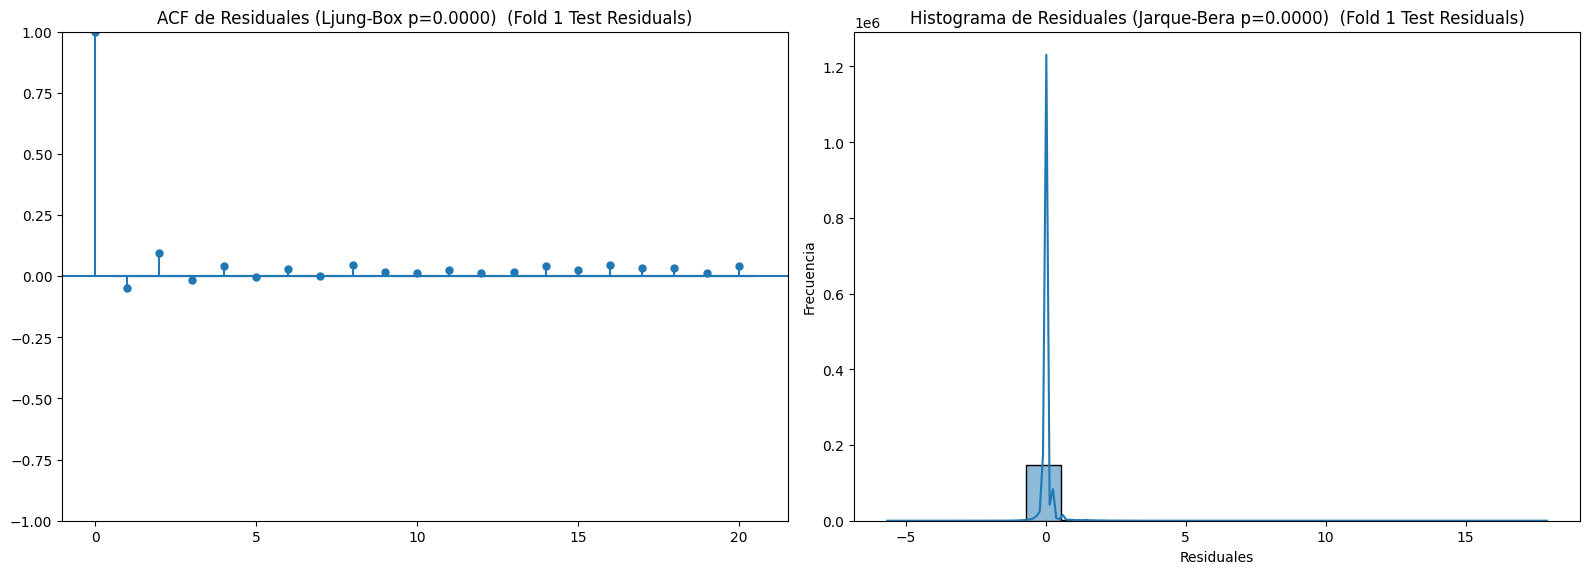


Procesando Fold 2/5...
  DEBUG - df_train_fold size: 336984, df_test_fold size: 150756
  Entrenamiento en 150 semanas (hasta temporal_id 149)
  Prueba en 67 semanas (de temporal_id 150 a 216)
  Tamaño Train: 336984, Tamaño Test: 150756
  DEBUG - Fitted GPs count for fold 2 (train): 2217
  DEBUG - Columns in df_results_test for fold 2: ['accident_count', 'Start_Lat', 'Start_Lng', 'lat_bin', 'lng_bin', 'Temperature_F', 'Wind_Speed_mph', 'Precipitation_in', 'Humidity_percent', 'Temperature_F_extreme', 'Wind_Speed_mph_extreme', 'Precipitation_in_extreme', 'Humidity_percent_extreme', 'Junction', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Signal', 'is_night', 'is_weekend', 'lat_min', 'lat_max', 'lng_min', 'lng_max', 'spatial_id', 'temporal_id_numeric', 'accident_count_transformed', 'stage1_preds', 'gp_mean', 'final_preds_transformed', 'final_uncertainty_transformed', 'final_preds_original_scale']
  DEBUG - NaNs in final_preds_original_scale for fold 2: 0 / 150756
  DEBUG - NaNs in

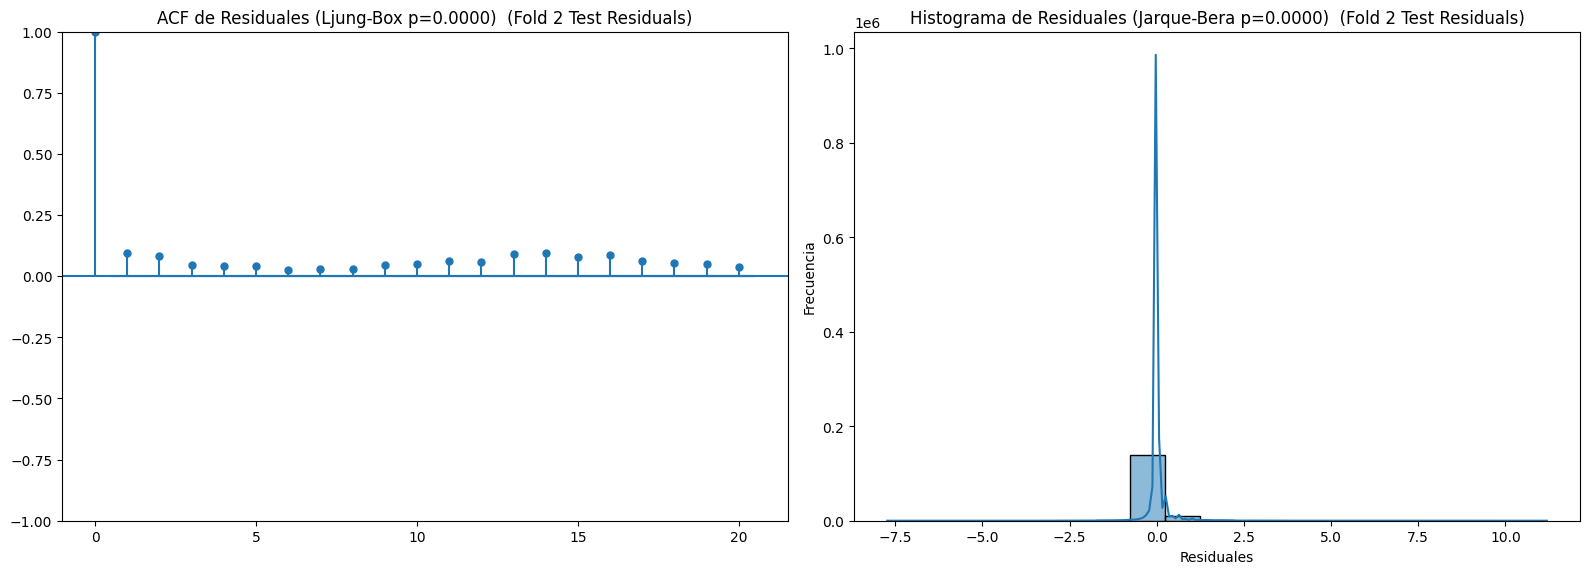


Procesando Fold 3/5...
  DEBUG - df_train_fold size: 487740, df_test_fold size: 150756
  Entrenamiento en 217 semanas (hasta temporal_id 216)
  Prueba en 67 semanas (de temporal_id 217 a 283)
  Tamaño Train: 487740, Tamaño Test: 150756
  DEBUG - Fitted GPs count for fold 3 (train): 2217
  DEBUG - Columns in df_results_test for fold 3: ['accident_count', 'Start_Lat', 'Start_Lng', 'lat_bin', 'lng_bin', 'Temperature_F', 'Wind_Speed_mph', 'Precipitation_in', 'Humidity_percent', 'Temperature_F_extreme', 'Wind_Speed_mph_extreme', 'Precipitation_in_extreme', 'Humidity_percent_extreme', 'Junction', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Signal', 'is_night', 'is_weekend', 'lat_min', 'lat_max', 'lng_min', 'lng_max', 'spatial_id', 'temporal_id_numeric', 'accident_count_transformed', 'stage1_preds', 'gp_mean', 'final_preds_transformed', 'final_uncertainty_transformed', 'final_preds_original_scale']
  DEBUG - NaNs in final_preds_original_scale for fold 3: 0 / 150756
  DEBUG - NaNs in

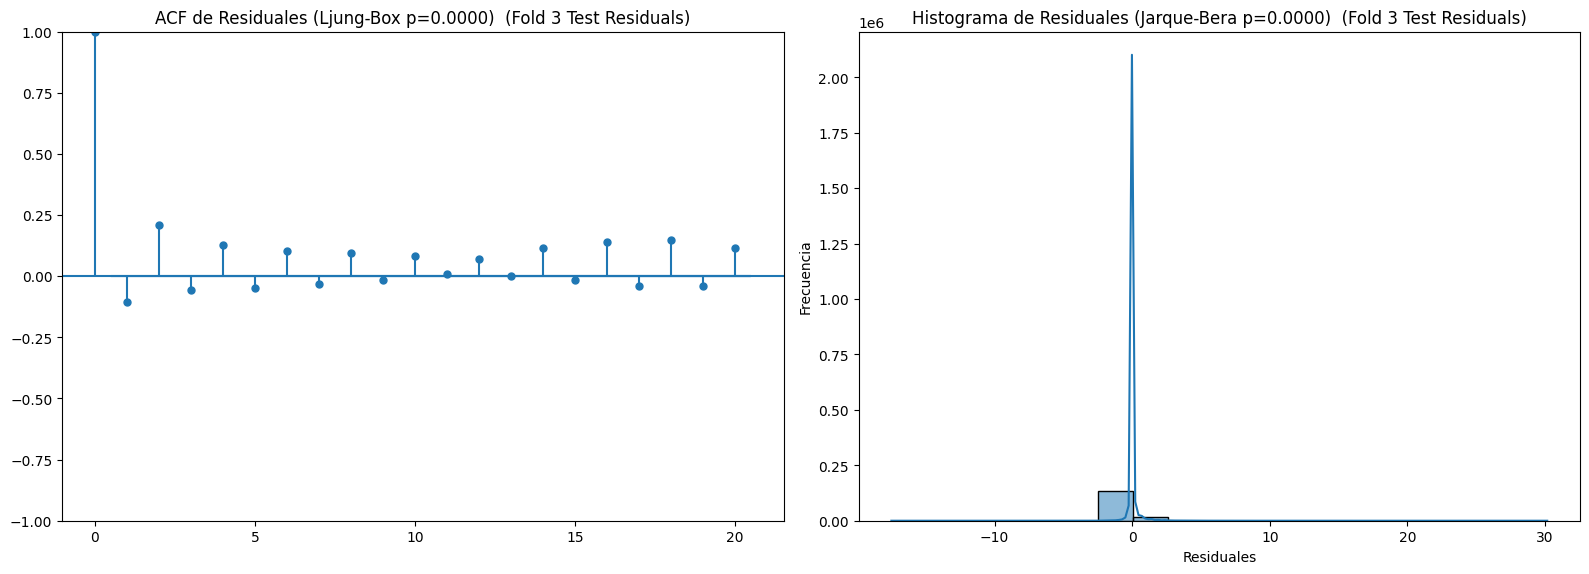


Procesando Fold 4/5...
  DEBUG - df_train_fold size: 638496, df_test_fold size: 150756
  Entrenamiento en 284 semanas (hasta temporal_id 283)
  Prueba en 67 semanas (de temporal_id 284 a 350)
  Tamaño Train: 638496, Tamaño Test: 150756
  DEBUG - Fitted GPs count for fold 4 (train): 2217
  DEBUG - Columns in df_results_test for fold 4: ['accident_count', 'Start_Lat', 'Start_Lng', 'lat_bin', 'lng_bin', 'Temperature_F', 'Wind_Speed_mph', 'Precipitation_in', 'Humidity_percent', 'Temperature_F_extreme', 'Wind_Speed_mph_extreme', 'Precipitation_in_extreme', 'Humidity_percent_extreme', 'Junction', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Signal', 'is_night', 'is_weekend', 'lat_min', 'lat_max', 'lng_min', 'lng_max', 'spatial_id', 'temporal_id_numeric', 'accident_count_transformed', 'stage1_preds', 'gp_mean', 'final_preds_transformed', 'final_uncertainty_transformed', 'final_preds_original_scale']
  DEBUG - NaNs in final_preds_original_scale for fold 4: 0 / 150756
  DEBUG - NaNs in

In [ ]:
if __name__ == '__main__':
    # Define aquí el porcentaje de datos a muestrear.
    # 1.0 para el dataset completo, 0.1 para el 10%, etc.
    sample_data_percentage = 0.3 # <-- CAMBIA ESTO PARA MUESTREAR TUS DATOS (ej. 0.1 para 10%)
    
    df_raw = pd.read_csv("california_accidents_cleaned_complete.csv")

    target_variable_input = 'accident_count'
    spatial_id_raw_col = 'zone_id'
    temporal_id_raw_col = 'year_week'

    covariables_a_usar_input = [
        'Temperature(F)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Humidity(%)',
        'Junction', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Signal',
        'is_night', 'is_weekend', 'Temperature(F)_extreme', 'Wind_Speed(mph)_extreme',
        'Precipitation(in)_extreme', 'Humidity(%)_extreme'
    ]
    covariables_a_usar_input = [col for col in covariables_a_usar_input if col in df_raw.columns]


    if df_raw.empty:
        print("El DataFrame de entrada está vacío. No se puede ejecutar el pipeline.")
    else:
        cols_to_clean_for_mapping = [target_variable_input] + covariables_a_usar_input
        cols_to_clean_for_mapping = [col for col in cols_to_clean_for_mapping if col in df_raw.columns]

        df_initial_cleaned, cleaned_names_list = clean_col_names(df_raw.copy(), cols_to_clean_for_mapping)
        original_to_cleaned_map = dict(zip(cols_to_clean_for_mapping, cleaned_names_list))
        
        target_variable_name_cleaned = original_to_cleaned_map.get(target_variable_input, target_variable_input)
        covariables_a_usar_cleaned = [original_to_cleaned_map.get(col, col) for col in covariables_a_usar_input]
        covariables_a_usar_cleaned = [col for col in covariables_a_usar_cleaned if col in df_initial_cleaned.columns]


        df_preprocessed_ids = parse_spatial_temporal_ids(df_initial_cleaned.copy())
        df_preprocessed_ids.sort_values(by=['temporal_id_numeric', 'spatial_id'], inplace=True)
        
        if sample_data_percentage < 1.0:
            all_spatial_ids = df_preprocessed_ids['spatial_id'].unique()
            np.random.seed(42)
            num_spatial_ids_to_sample = max(1, int(len(all_spatial_ids) * sample_data_percentage))
            sampled_spatial_ids = np.random.choice(all_spatial_ids, num_spatial_ids_to_sample, replace=False)
            
            df_preprocessed_ids = df_preprocessed_ids[df_preprocessed_ids['spatial_id'].isin(sampled_spatial_ids)].copy()
            print(f"\nSe ha muestreado el dataset: {len(sampled_spatial_ids)} de {len(all_spatial_ids)} zonas espaciales seleccionadas ({sample_data_percentage*100:.1f}%).")
            print(f"Nuevo tamaño del dataset muestreado: {len(df_preprocessed_ids)} filas.")

        unique_temporal_ids = df_preprocessed_ids['temporal_id_numeric'].unique()
        unique_temporal_ids.sort()

        n_splits = 5
        
        min_train_weeks_ratio = 0.2
        min_train_weeks_count = int(len(unique_temporal_ids) * min_train_weeks_ratio)
        if min_train_weeks_count < 2:
            min_train_weeks_count = 2

        available_for_test = unique_temporal_ids[min_train_weeks_count:]
        fold_size = len(available_for_test) // n_splits
        if fold_size == 0 and len(available_for_test) > 0:
            fold_size = 1 
        elif fold_size == 0 and len(available_for_test) == 0:
            print("No hay suficientes datos temporales para crear folds de prueba después del conjunto de entrenamiento inicial.")
            exit()


        all_metrics = []
        all_df_results_test_combined = pd.DataFrame()

        print(f"\n--- Iniciando Validación Cruzada Leave-Time-Out (LTO) Estricta con {n_splits} folds ---")

        y_true_train_for_mase_all_folds = pd.Series(dtype=float)

        for i in range(n_splits):
            print(f"\nProcesando Fold {i+1}/{n_splits}...")
            
            start_idx_test = min_train_weeks_count + (i * fold_size)
            
            if start_idx_test >= len(unique_temporal_ids):
                print(f"Fold {i+1}: No hay más IDs temporales para crear el conjunto de prueba. Terminando folds.")
                break

            test_temporal_ids_current_fold = unique_temporal_ids[start_idx_test : start_idx_test + fold_size]
            
            if len(test_temporal_ids_current_fold) == 0:
                print(f"Fold {i+1}: Conjunto de prueba vacío en este bloque. Saltando.")
                continue

            train_temporal_ids_current_fold = unique_temporal_ids[unique_temporal_ids < test_temporal_ids_current_fold.min()]
            
            df_train_fold = df_preprocessed_ids[df_preprocessed_ids['temporal_id_numeric'].isin(train_temporal_ids_current_fold)].copy()
            df_test_fold = df_preprocessed_ids[df_preprocessed_ids['temporal_id_numeric'].isin(test_temporal_ids_current_fold)].copy()

            print(f"  DEBUG - df_train_fold size: {len(df_train_fold)}, df_test_fold size: {len(df_test_fold)}")

            if df_train_fold.empty:
                print(f"Fold {i+1}: Conjunto de entrenamiento vacío ({len(train_temporal_ids_current_fold)} semanas). Necesitas más datos de historial inicial. Saltando este fold.")
                continue
            if df_test_fold.empty:
                print(f"Fold {i+1}: Conjunto de prueba vacío ({len(test_temporal_ids_current_fold)} semanas). Saltando este fold.")
                continue

            print(f"  Entrenamiento en {len(train_temporal_ids_current_fold)} semanas (hasta temporal_id {train_temporal_ids_current_fold.max() if len(train_temporal_ids_current_fold) > 0 else 'N/A'})")
            print(f"  Prueba en {len(test_temporal_ids_current_fold)} semanas (de temporal_id {test_temporal_ids_current_fold.min()} a {test_temporal_ids_current_fold.max()})")
            print(f"  Tamaño Train: {len(df_train_fold)}, Tamaño Test: {len(df_test_fold)}")

            df_results_train, fitted_gps_for_predict = run_st_gpr_pipeline(
                input_df=df_train_fold,
                target_variable_name=target_variable_name_cleaned,
                spatial_id_col='spatial_id',
                temporal_id_col='temporal_id_numeric',
                covariate_list=covariables_a_usar_cleaned,
                sigma_smooth_val=0.5,
                gp_kernel_type='Matern52',
                transformation_type='log',
                model_type_stage1='OLS',
                mode='train'
            )
            
            y_true_train_for_mase_all_folds = pd.concat([y_true_train_for_mase_all_folds, df_results_train[target_variable_name_cleaned]])

            print(f"  DEBUG - Fitted GPs count for fold {i+1} (train): {len(fitted_gps_for_predict)}")

            if not fitted_gps_for_predict:
                print(f"Fold {i+1}: No se pudieron entrenar GPs válidos. Saltando predicción para este fold.")
                continue

            df_results_test = run_st_gpr_pipeline(
                input_df=df_test_fold,
                target_variable_name=target_variable_name_cleaned,
                spatial_id_col='spatial_id',
                temporal_id_col='temporal_id_numeric',
                covariate_list=covariables_a_usar_cleaned,
                sigma_smooth_val=0.5,
                gp_kernel_type='Matern52',
                transformation_type='log',
                model_type_stage1='OLS',
                mode='predict',
                trained_gps_dict=fitted_gps_for_predict
            )

            actual_col_for_metrics = target_variable_name_cleaned
            
            print(f"  DEBUG - Columns in df_results_test for fold {i+1}: {df_results_test.columns.tolist()}")
            if 'final_preds_original_scale' in df_results_test.columns:
                print(f"  DEBUG - NaNs in final_preds_original_scale for fold {i+1}: {df_results_test['final_preds_original_scale'].isnull().sum()} / {len(df_results_test)}")
            if actual_col_for_metrics in df_results_test.columns:
                print(f"  DEBUG - NaNs in actual_col_for_metrics for fold {i+1}: {df_results_test[actual_col_for_metrics].isnull().sum()} / {len(df_results_test)}")
            
            if 'final_preds_original_scale' in df_results_test.columns and actual_col_for_metrics in df_results_test.columns:
                temp_y_true = df_results_test[actual_col_for_metrics]
                temp_y_pred = df_results_test['final_preds_original_scale']
                common_index_count = temp_y_true.dropna().index.intersection(temp_y_pred.dropna().index).shape[0]
                print(f"  DEBUG - Valid data points for metrics in fold {i+1}: {common_index_count}")
                if common_index_count == 0:
                    print(f"Fold {i+1}: No hay suficientes puntos de datos válidos para calcular métricas después de eliminar NaNs.")

            if 'final_preds_original_scale' in df_results_test.columns and actual_col_for_metrics in df_results_test.columns:
                metrics_fold = calculate_metrics(
                    df_results_test[actual_col_for_metrics],
                    df_results_test['final_preds_original_scale'],
                    y_name=f"Fold {i+1}",
                    y_true_train_for_mase=y_true_train_for_mase_all_folds
                )
                print(f"  Métricas del Fold {i+1}: RMSE={metrics_fold['RMSE']:.4f}, MAE={metrics_fold['MAE']:.4f}, MAPE={metrics_fold['MAPE']:.4f}%, SMAPE={metrics_fold['SMAPE']:.4f}%, MASE={metrics_fold['MASE']:.4f}, R2={metrics_fold['R2']:.4f}, Ljung-Box p-valor={metrics_fold['Ljung-Box p-valor']:.4f}, Jarque-Bera p-valor={metrics_fold['Jarque-Bera p-valor']:.4f} (Count={metrics_fold['Count']})")
                
                # ## --- CAMBIO: NUEVO - Graficar diagnósticos de residuales por fold --- ##
                plot_residuals_diagnostics(
                    metrics_fold['Residuals'],
                    metrics_fold['Ljung-Box p-valor'],
                    metrics_fold['Jarque-Bera p-valor'],
                    title_suffix=f" (Fold {i+1} Test Residuals)"
                )
                # ######################################################################
                
                if metrics_fold['Count'] > 0:
                    all_metrics.append(metrics_fold)
                    all_df_results_test_combined = pd.concat([all_df_results_test_combined, df_results_test])
                else:
                    print(f"Fold {i+1}: Métricas no válidas (Count=0), no se añadirán a all_metrics.")
            else:
                print(f"No se pudieron calcular las métricas para el Fold {i+1}: columnas de resultados o variable objetivo no encontradas.")


        print("\n--- Resumen de Métricas de Validación Cruzada (Leave-Time-Out) ---")
        metrics_df = pd.DataFrame(all_metrics)
        print(metrics_df[['RMSE', 'MAE', 'MAPE', 'SMAPE', 'MASE', 'R2', 'Ljung-Box p-valor', 'Jarque-Bera p-valor', 'Count']].round(4))
        print("\nMétricas Promedio:")
        print(metrics_df[['RMSE', 'MAE', 'MAPE', 'SMAPE', 'MASE', 'R2', 'Ljung-Box p-valor', 'Jarque-Bera p-valor', 'Count']].mean(numeric_only=True).round(4))
        print("\nMétricas Desviación Estándar:")
        print(metrics_df[['RMSE', 'MAE', 'MAPE', 'SMAPE', 'MASE', 'R2', 'Ljung-Box p-valor', 'Jarque-Bera p-valor', 'Count']].std(numeric_only=True).round(4))

        if not all_df_results_test_combined.empty:
            spatial_col_for_plot = 'spatial_id'
            temporal_col_for_plot = 'temporal_id_numeric'
            target_col_for_plot = target_variable_name_cleaned

            zones_with_accidents = all_df_results_test_combined[all_df_results_test_combined[target_col_for_plot] > 0]['spatial_id'].unique()

            if len(zones_with_accidents) > 0:
                zona_para_graficar_val = zones_with_accidents[0]
                print(f"\nGraficando resultados para la zona con al menos un accidente reportado: {zona_para_graficar_val}")
            else:
                zona_para_graficar_val = all_df_results_test_combined[spatial_col_for_plot].unique()[0]
                print(f"\nAdvertencia: No se encontraron zonas con valores de '{target_col_for_plot}' > 0 en los resultados combinados de prueba. Graficando la primera zona disponible: {zona_para_graficar_val}")
            
            if spatial_col_for_plot in all_df_results_test_combined.columns and all_df_results_test_combined[spatial_col_for_plot].nunique() > 0:
                plot_region_results(
                    df=all_df_results_test_combined,
                    region_id_to_plot=zona_para_graficar_val,
                    actual_col=target_col_for_plot,
                    pred_col_transformed='final_preds_transformed',
                    uncertainty_col_transformed='final_uncertainty_transformed',
                    pred_col_original='final_preds_original_scale',
                    spatial_col=spatial_col_for_plot,
                    temporal_col=temporal_col_for_plot,
                    transformation='log',
                    title_suffix="(Resultados Combinados de Validación LTO)"
                )
            else:
                print("\nNo hay datos suficientes para graficar resultados después de la validación cruzada.")
        else:
            print("\nNo se generaron resultados de folds para graficar.")